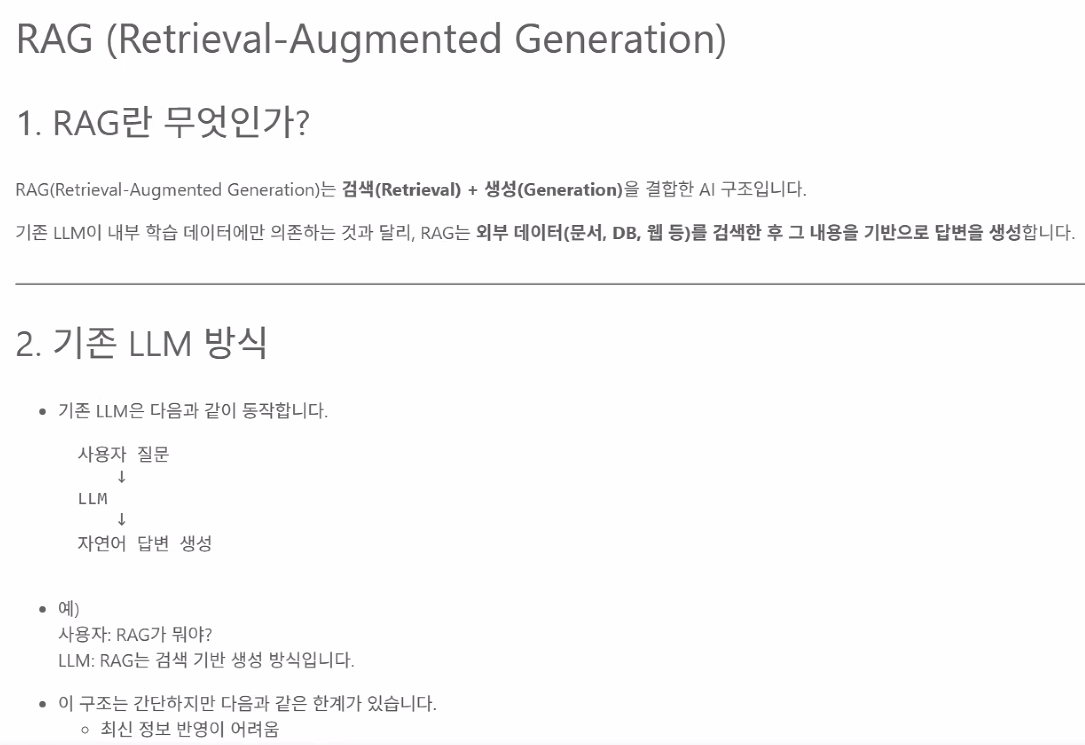

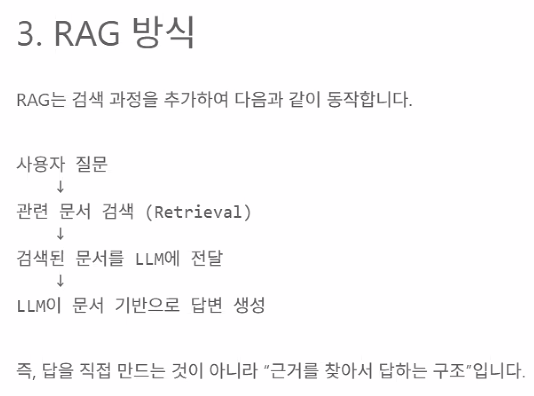

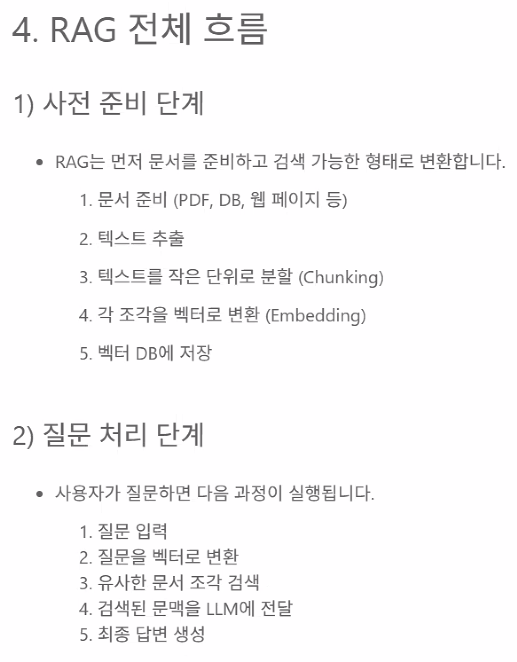

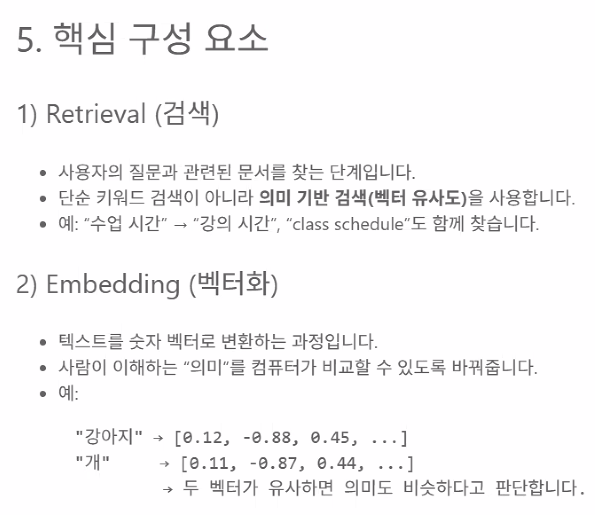

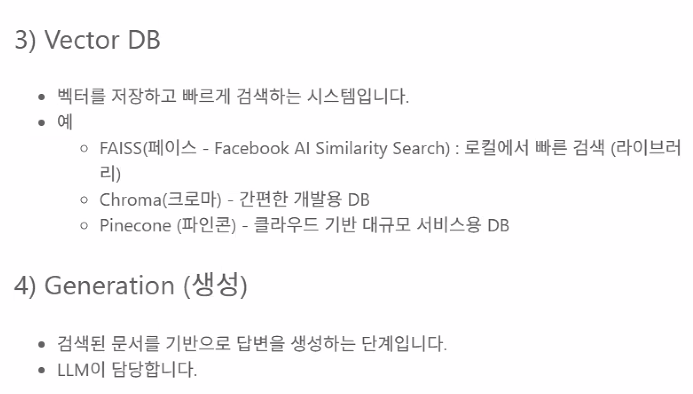

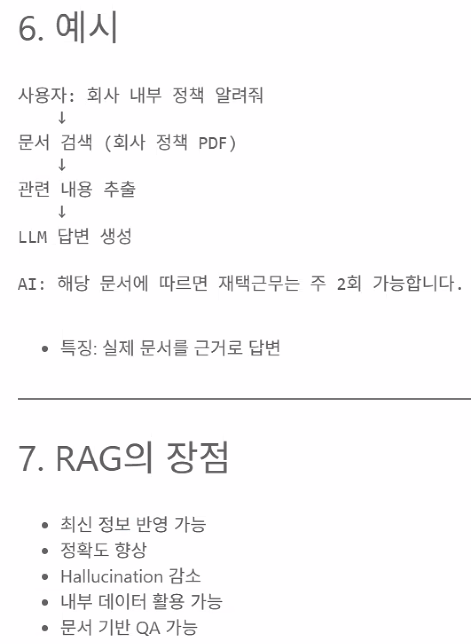

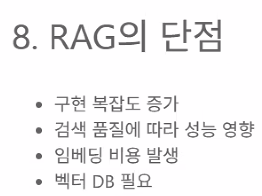

In [16]:
%pip install pypdf

Note: you may need to restart the kernel to use updated packages.


In [17]:
import pypdf
print(pypdf.__version__)

6.9.2


In [18]:
from pathlib import Path

def load_text_from_file(file_path: str) -> str:
    return Path(file_path).read_text(encoding="utf-8")

pdf_text = load_text_from_file("../data/Pilates.txt")
print(pdf_text)

  필라테스 센터 운영 규칙집

본 규칙집은 필라테스 센터의 효율적인 운영과 서비스 품질의 일관성을 유지하며, 모든 회원의 안전과 만족도를 극대화하기 위해 제정된 공식 운영 지침서입니다. 본 문서는 센터 관리자, 강사, 운영 스태프뿐만 아니라 센터를 이용하는 모든 회원과 외부 협력자가 반드시 숙지하고 준수해야 하는 기준을 포함하고 있습니다. 모든 운영 기준은 회원의 건강과 안전을 최우선으로 고려하여 설계되었으며, 지속적인 서비스 품질 향상을 목표로 합니다.

   1. 센터 운영 및 시설 이용 규정

본 센터는 회원들에게 안정적이고 체계적인 운동 환경을 제공하기 위해 운영 시간과 수업 구성에 대한 명확한 기준을 설정하고 있습니다. 평일에는 오전 7시부터 오후 10시까지 운영되며, 주말 및 공휴일에는 오전 9시부터 오후 6시까지 운영됩니다. 이는 다양한 생활 패턴을 가진 회원들이 편리하게 이용할 수 있도록 고려한 시간 운영 정책입니다.

모든 정규 수업은 50분 동안 진행되며, 수업 전후로 각각 10분의 준비 및 정리 시간이 배정됩니다. 준비 시간은 회원들이 충분한 스트레칭과 컨디션 점검을 할 수 있도록 돕고, 정리 시간은 기구 정리 및 다음 수업을 위한 환경 정비를 목적으로 합니다.

회원은 수업 시작 최소 10분 전에 입실하는 것을 권장하며, 이는 안전한 운동을 위한 사전 준비를 가능하게 합니다. 수업에 지각할 경우 충분한 준비 운동 없이 운동을 시작하게 되어 부상의 위험이 증가할 수 있으므로, 상황에 따라 입실이 제한될 수 있습니다.

또한, 필라테스 운동의 특성상 정확한 자세 교정과 안전 확보를 위해 전용 운동복 착용이 필수이며, 미끄럼 방지 양말을 반드시 착용해야 합니다. 이는 기구 사용 시 발생할 수 있는 사고를 예방하기 위한 중요한 안전 수칙입니다.

    1.1 운영 시간 및 수업 시간

- 평일: 07:00 ~ 22:00
- 주말: 09:00 ~ 18:00
- 공휴일: 사전 공지 시 운영

    1.2 휴무 및 정기 점검

- 매월 마지막 주

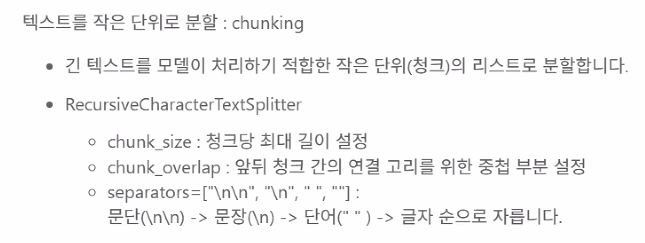

In [19]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

def split_text_into_chunks(text: str, chunk_size: int = 1000, chunk_overlap: int = 150) -> list[str]:
    """
    긴 텍스트를 RAG에 적합한 크기의 청크 리스트로 분할합니다.
    """
    if not text or not text.strip():
        return []

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", " ", ""] # 문맥 보존을 위한 구분자 설정
    )
    return splitter.split_text(text)

In [20]:
chunks = split_text_into_chunks(text=pdf_text, chunk_size=500, chunk_overlap=50)

In [21]:
print(len(chunks))
for i, chunk in enumerate(chunks):
    print(f"{i+1}번째 청크")
    print(chunk[0:50])
    print()

22
1번째 청크
필라테스 센터 운영 규칙집

본 규칙집은 필라테스 센터의 효율적인 운영과 서비스 품질의 일

2번째 청크
모든 정규 수업은 50분 동안 진행되며, 수업 전후로 각각 10분의 준비 및 정리 시간이 

3번째 청크
1.2 휴무 및 정기 점검

- 매월 마지막 주 일요일 설비 점검
- 공지된 휴무일 외 비

4번째 청크
2.1 회원 등록

회원 등록은 센터 이용의 시작 단계로서, 정확한 정보 제공과 사전 건강

5번째 청크
센터는 해당 정보를 기반으로 회원에게 적절한 운동 강도와 프로그램을 제안하며, 필요 시 특

6번째 청크
모든 이용권은 정해진 유효기간 내에 사용해야 하며, 기간 내 사용하지 못한 잔여 회차는 환

7번째 청크
특히 건강 상태와 관련된 정보는 운동 중 안전과 직결되므로, 작은 변화라도 반드시 공유해야

8번째 청크
수강권은 원칙적으로 본인 사용을 기준으로 하지만, 불가피한 사정이 발생할 경우 가족 또는 

9번째 청크
3.1. 예약 원칙

센터에서 제공되는 모든 수업은 사전 예약을 원칙으로 운영됩니다. 회원

10번째 청크
그룹 레슨의 경우에는 상대적으로 많은 인원이 참여하는 특성을 고려하여, 수업 시작 12시간

11번째 청크
이미 수업이 진행 중인 상황에서 입장을 요청할 경우에는 강사의 판단에 따라 참여 여부가 결

12번째 청크
3.5.  변경 시스템

센터는 효율적인 수업 운영을 위해 전용 모바일 애플리케이션을 통한

13번째 청크
4. 취소 및 노쇼(No-Show) 규정

수업 취소는 일정 기준에 따라 차감 규정이 적용

14번째 청크
정지 기간은 1회 신청 시 최소 2주에서 최대 4주까지 가능하며, 전체 수강권 기간 동안 

15번째 청크
센터 내 시설 및 기물을 고의 또는 과실로 파손할 경우, 해당 회원은 원상 복구에 대한 책

16번째 청크
9. 오리엔테이션(OT) 및 사후 관리

신규 회원은 센터 이용 전 반드시 1회의 오리엔테

17번째 청크
10.1 안전 수칙

모든 회원은 기구 사용 전 반드시 강사의 지도와

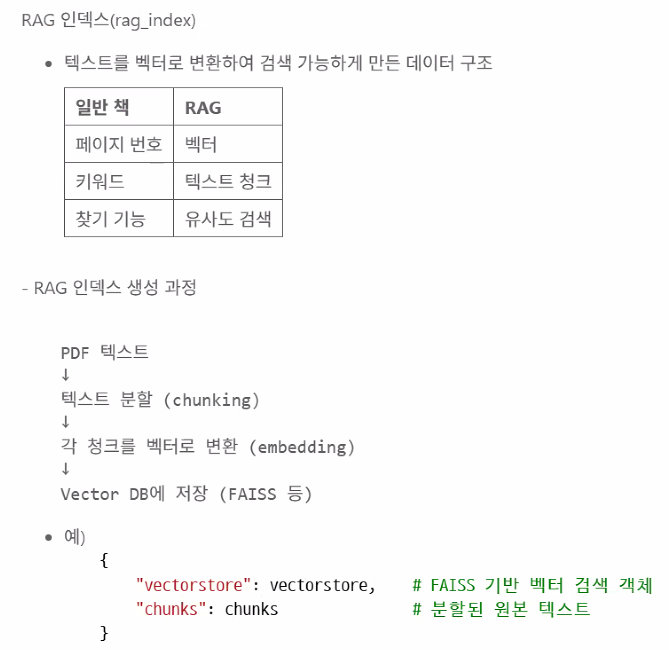

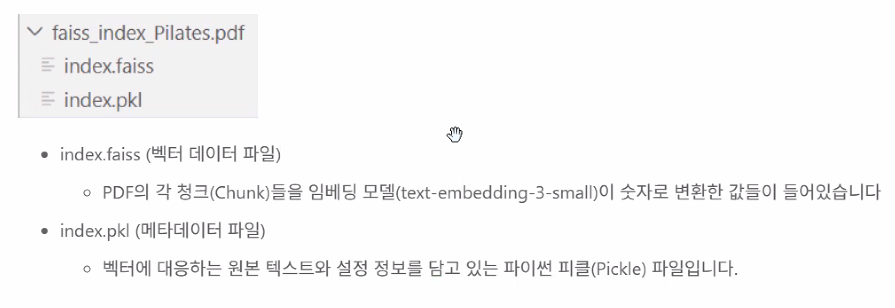

In [22]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
# 벡터 DB (유사도 검색용)
from langchain_community.vectorstores import FAISS
from pathlib import Path
from dotenv import load_dotenv
import os

load_dotenv()

def get_embeddings():
    """
    OpenAI의 최신 임베딩 모델을 사용하여 텍스트를 수치형 벡터로 변환하는 객체를 생성합니다.
    'text-embedding-3-small'은 가성비와 성능이 뛰어난 모델입니다.
    """
    return OpenAIEmbeddings(
        model="text-embedding-3-small"
    )

def build_rag_index(pdf_text: str, file_name: str) -> dict | None:
    """
    분할된 텍스트를 바탕으로 FAISS 벡터 인덱스를 생성하거나 로드합니다.
    """

    # 분리된 메서드를 호출하여 긴 텍스트를 작은 조각(chunks)으로 분할
    chunks = split_text_into_chunks(pdf_text)

    # 분할된 내용이 없으면(텍스트가 비어있으면) 처리를 중단
    if not chunks:
        return None

    # 임베딩 모델 가져오기
    embeddings = get_embeddings()

    # FAISS 저장 경로
    index_path = Path(f"faiss_index_{file_name}")

    # 기존 인덱스(벡터 검색용 데이터)가 있으면 로드
    if index_path.exists():
        # 로컬에 저장된 FAISS 인덱스를 메모리로 불러옵니다.
        # FAISS는 벡터 "검색 엔진"이며, LangChain이 감싸서 vector store 형태로 제공합니다.
        # DB처럼 사용할 수 있지만, 실제 데이터베이스는 아닙니다.
        vectorstore = FAISS.load_local(
            str(index_path),
            embeddings,
            allow_dangerous_deserialization=True  # FAISS 인덱스는 내부적으로 pickle 형식으로 저장
                                                # pickle은 Python 객체를 파일로 저장하고 다시 복원
                                                # 문제: 복원 과정에서 코드 실행이 가능하기 때문에
                                                # allow_dangerous_deserialization=True 의미는 "이 파일은 내가 생성한 것이니 안전하다"고 보증하는 것입니다.
        )
    # 없으면 새로 생성 + 저장
    else:
        # FAISS.from_texts:
        # 텍스트(chunks)를 임베딩 모델로 벡터로 변환
        # FAISS 인덱스 생성 (유사도 검색용)
        # LangChain이 이를 감싸 vector store 형태로 구성 (DB처럼 사용 가능)
        vectorstore = FAISS.from_texts(chunks, embeddings)

        # 생성된 vector store를 로컬 파일로 저장합니다.
        # -> index.faiss : 벡터 인덱스 (검색용)
        # -> index.pkl   : 문서 및 메타데이터
        # 다음 실행 시 재사용 가능 (속도 향상)
        vectorstore.save_local(str(index_path))

    # RAG 인덱스 구조 반환
    return {
        "vectorstore": vectorstore,  # 검색용 DB
        "chunks": chunks             # 원본 텍스트 조각
    }

In [23]:
rag_index = build_rag_index(pdf_text, "Pilates")

In [24]:
question = "회원 등록"
top_k = 5

In [25]:
vectorstore = rag_index.get("vectorstore")

# 질문과 가장 유사한 문서 검색
# k=top_k : 가장 유사한 문서 5개 반환
docs = vectorstore.similarity_search(question, k=top_k)

In [26]:
# 문서 내용만 추출
# docs는 Document 객체 리스트 형태
# page_content: 실제 텍스트 내용
retrieved_chunks = [doc.page_content for doc in docs]

# 검색 결과를 하나의 문자열로 합침
context_text = "\n\n".join(retrieved_chunks) if retrieved_chunks else "관련 문서를 찾지 못했습니다."

In [27]:
print(context_text)

1.1 운영 시간 및 수업 시간

- 평일: 07:00 ~ 22:00
- 주말: 09:00 ~ 18:00
- 공휴일: 사전 공지 시 운영

    1.2 휴무 및 정기 점검

- 매월 마지막 주 일요일 설비 점검
- 공지된 휴무일 외 비정상 휴무 발생 시 24시간 이전 안내 필수

    1.3 센터 출입 규칙

- 회원 본인만 출입 가능
- 예약 시간 10분 전부터 입실 가능
- 외부 음식 반입 금지(물은 허용)

    1.4 수업 시간 규정

- 개인 레슨: 50분 수업 + 10분 정리 시간
- 듀엣 레슨: 50분 수업
- 그룹 레슨: 50~55분 수업
- 워밍업, 쿨다운 포함 운영
- 수업 간 지연 금지

  2. 회원 관리 규정

본 장은 회원 등록부터 이용권 관리, 회원 정보 변경에 이르기까지 회원과 센터 간의 기본적인 관리 기준을 정의하는 항목입니다. 회원 관리 규정은 정확한 정보 기반의 안전한 운동 환경을 조성하고, 체계적인 서비스 제공을 가능하게 하기 위한 중요한 기준으로 작용합니다. 모든 회원은 본 규정을 충분히 이해하고 준수해야 하며, 센터 역시 회원 정보를 안전하게 관리할 책임을 가집니다.

   2.1 회원 등록

회원 등록은 센터 이용의 시작 단계로서, 정확한 정보 제공과 사전 건강 상태 확인을 기반으로 이루어집니다. 모든 회원은 가입 절차 진행 시 개인정보 수집 및 이용에 대한 동의 절차를 반드시 완료해야 하며, 이는 서비스 제공 및 안전 관리 목적에 한해 사용됩니다.

또한, 회원은 등록 시 건강 상태 설문지를 반드시 작성해야 합니다. 해당 설문에는 요통 여부, 임신 여부, 과거 수술 이력, 현재 치료 중인 질환, 운동 시 주의가 필요한 신체 상태 등 다양한 항목이 포함됩니다. 이는 단순한 형식적인 절차가 아니라, 회원 개인의 신체 상태에 맞는 안전한 운동 프로그램을 설계하기 위한 필수적인 과정입니다.

센터는 해당 정보를 기반으로 회원에게 적절한 운동 강도와 프로그램을 제안하며, 필요 시 특정 동작 제한 또는 개별 맞춤 지도를 제

In [28]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

llm = ChatOpenAI(
    model="gpt-4.1-nano",
    temperature=0  # 0 = 항상 일관된 답변 (RAG에 적합)
)

messages = [
    SystemMessage(content="""
당신은 RAG 도우미입니다.
문서 기반으로만 답하세요.
"""),
    HumanMessage(content=f"""
[문서]
{context_text}

[질문]
{question}
""")
]

response = llm.invoke(messages)

print(response.content)

회원 등록은 센터 이용의 시작 단계로서, 정확한 정보 제공과 사전 건강 상태 확인을 기반으로 이루어집니다. 모든 회원은 가입 절차 진행 시 개인정보 수집 및 이용에 대한 동의 절차를 반드시 완료해야 하며, 이는 서비스 제공 및 안전 관리 목적에 한해 사용됩니다. 또한, 회원은 등록 시 건강 상태 설문지를 반드시 작성해야 하며, 해당 설문에는 요통 여부, 임신 여부, 과거 수술 이력, 현재 치료 중인 질환, 운동 시 주의가 필요한 신체 상태 등 다양한 항목이 포함됩니다. 센터는 해당 정보를 기반으로 회원에게 적절한 운동 강도와 프로그램을 제안하며, 필요 시 특정 동작 제한 또는 개별 맞춤 지도를 제공할 수 있습니다. 회원은 자신의 건강 상태를 정확하게 기재해야 하며, 고의 또는 과실로 중요한 정보를 누락할 경우 발생할 수 있는 문제에 대해서는 본인에게 책임이 있을 수 있습니다.
